# Visualize train/0 — View 1 and View 2
Shows the two source views alongside the reference (avg face) and morphed face, with GT transforms applied.

In [11]:
import os, torch, pickle
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from pathlib import Path

# Walk up from cwd until we find data/faces/metadata/train.pkl
_marker = Path('data/faces/metadata/train.pkl')
_root = None
for _p in [Path.cwd()] + list(Path.cwd().parents):
    if (_p / _marker).exists():
        _root = _p
        break
if _root is None:
    raise RuntimeError(
        f"Could not find repo root (looked for {_marker} up from {Path.cwd()}). "
        "Set REPO_ROOT manually below."
    )
# REPO_ROOT = Path('/your/path/here')  # uncomment and set if auto-detect fails
REPO_ROOT = _root
os.chdir(REPO_ROOT)
print('Repo root:', REPO_ROOT)

DATA_ROOT = 'data/faces/data'
META_PATH = 'data/faces/metadata/train.pkl'
SCENE = '16'

Repo root: /workspace/src


In [12]:
# Load metadata entries for this scene
with open(META_PATH, 'rb') as f:
    meta = pickle.load(f)

entries = [m for m in meta if str(m['scene_name']) == SCENE]
entries.sort(key=lambda m: m['frag_id1'])  # view_1 before view_2
print(f'{len(entries)} entries found for scene {SCENE}')
for e in entries:
    print(f"  frag_id1={e['frag_id1']}  pcd1={e['pcd1']}  kept={e['kept_indices'].shape[0]}")

2 entries found for scene 16
  frag_id1=1  pcd1=train/16/view_1.pth  kept=3212
  frag_id1=2  pcd1=train/16/view_2.pth  kept=3580


In [13]:
# Load point clouds
avg_ref = torch.load(f"{DATA_ROOT}/average_face.pth", weights_only=False)
morphed  = torch.load(f"{DATA_ROOT}/{entries[0]['pcd_morphed']}", weights_only=False)
view1    = torch.load(f"{DATA_ROOT}/{entries[0]['pcd1']}", weights_only=False)
view2    = torch.load(f"{DATA_ROOT}/{entries[1]['pcd1']}", weights_only=False)

R1, t1 = entries[0]['rotation'], entries[0]['translation']
R2, t2 = entries[1]['rotation'], entries[1]['translation']

# Apply GT transform to bring src back into ref frame
# GT: ref = R @ src + t  =>  src_aligned = R.T @ (src - t)
def apply_gt(pts, R, t):
    return (pts - t) @ R  # equivalent to R.T @ (pts - t).T transposed back

view1_aligned = apply_gt(view1, R1, t1)
view2_aligned = apply_gt(view2, R2, t2)

print('avg_ref:', avg_ref.shape)
print('morphed: ', morphed.shape)
print('view1:  ', view1.shape, '  (raw, in src frame)')
print('view2:  ', view2.shape, '  (raw, in src frame)')

avg_ref: (10788, 3)
morphed:  (10788, 3)
view1:   (3212, 3)   (raw, in src frame)
view2:   (3580, 3)   (raw, in src frame)


In [14]:
def scatter3(ax, pts, c, label, s=1, alpha=0.5):
    ax.scatter(pts[:,0], pts[:,1], pts[:,2], c=c, s=s, alpha=alpha, label=label)

def set_equal_axes(ax):
    """Force equal aspect ratio on a 3D axis."""
    pts_all = []
    for coll in ax.collections:
        o = coll._offsets3d
        if o is not None:
            pts_all.append(np.column_stack(o))
    if not pts_all:
        return
    pts = np.vstack(pts_all)
    mn, mx = pts.min(0), pts.max(0)
    mid = (mn + mx) / 2
    r = (mx - mn).max() / 2
    ax.set_xlim(mid[0]-r, mid[0]+r)
    ax.set_ylim(mid[1]-r, mid[1]+r)
    ax.set_zlim(mid[2]-r, mid[2]+r)

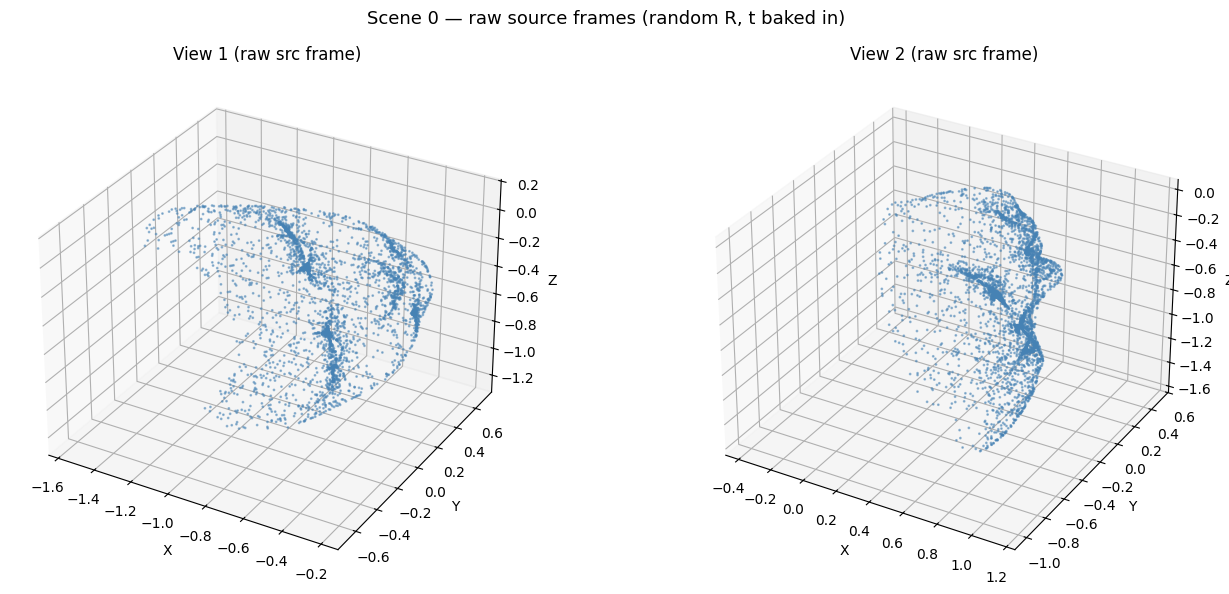

In [15]:
# --- Figure 1: raw src frames (how the data arrives before GT alignment) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={'projection': '3d'})

for ax, view, label in zip(axes, [view1, view2], ['View 1 (raw src frame)', 'View 2 (raw src frame)']):
    scatter3(ax, view, 'steelblue', 'src', s=1)
    ax.set_title(label)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    set_equal_axes(ax)

fig.suptitle('Scene 0 — raw source frames (random R, t baked in)', fontsize=13)
plt.tight_layout()
plt.show()

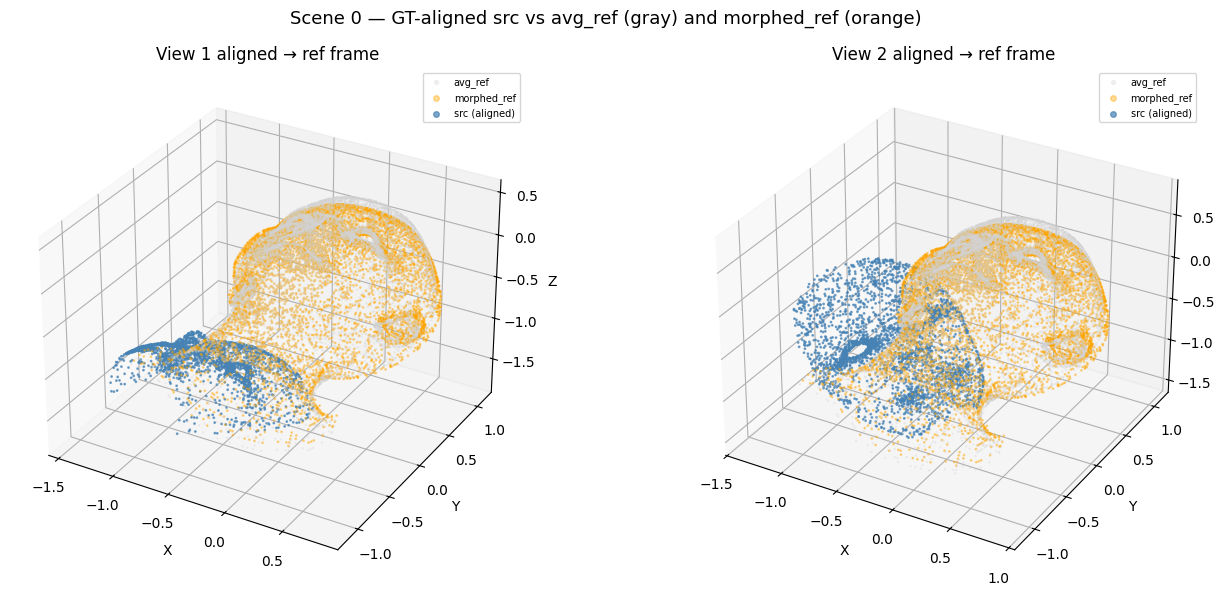

In [16]:
# --- Figure 2: GT-aligned views overlaid on avg_ref and morphed ref ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={'projection': '3d'})

for ax, view_a, label in zip(axes,
                              [view1_aligned, view2_aligned],
                              ['View 1 aligned → ref frame', 'View 2 aligned → ref frame']):
    scatter3(ax, avg_ref,  'lightgray', 'avg_ref',        s=0.5, alpha=0.3)
    scatter3(ax, morphed,  'orange',    'morphed_ref',    s=1,   alpha=0.4)
    scatter3(ax, view_a,   'steelblue', 'src (aligned)',  s=1,   alpha=0.7)
    ax.set_title(label)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.legend(markerscale=4, fontsize=7)
    set_equal_axes(ax)

fig.suptitle('Scene 0 — GT-aligned src vs avg_ref (gray) and morphed_ref (orange)', fontsize=13)
plt.tight_layout()
plt.show()

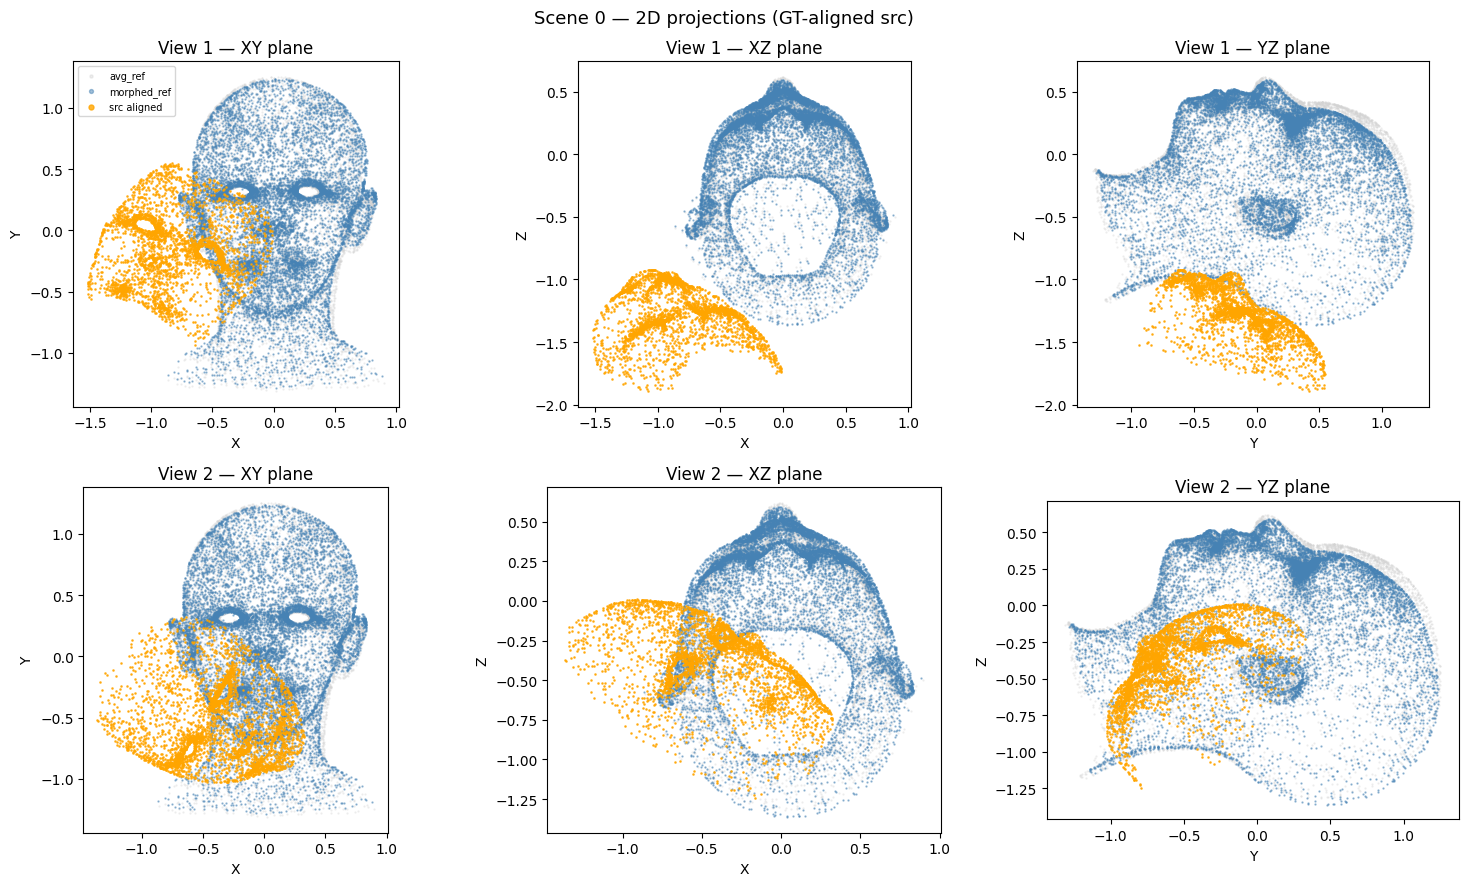

In [18]:
# --- Figure 3: orthographic projections (XY, XZ, YZ) for quick sanity check ---
projs = [('XY', 0, 1), ('XZ', 0, 2), ('YZ', 1, 2)]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for row, (view_a, view_lbl) in enumerate([(view1_aligned, 'View 1'), (view2_aligned, 'View 2')]):
    for col, (plane, xi, yi) in enumerate(projs):
        ax = axes[row, col]
        ax.scatter(avg_ref[:,xi],  avg_ref[:,yi],  s=0.3, c='lightgray', label='avg_ref',     alpha=0.4)
        ax.scatter(morphed[:,xi],  morphed[:,yi],  s=0.5, c='steelblue',    label='morphed_ref', alpha=0.5)
        ax.scatter(view_a[:,xi],   view_a[:,yi],   s=0.8, c='orange', label='src aligned', alpha=0.8)
        ax.set_title(f'{view_lbl} — {plane} plane')
        ax.set_aspect('equal')
        ax.set_xlabel(plane[0]); ax.set_ylabel(plane[1])
        if row == 0 and col == 0:
            ax.legend(markerscale=4, fontsize=7)

fig.suptitle('Scene 0 — 2D projections (GT-aligned src)', fontsize=13)
plt.tight_layout()
plt.show()